# 1 - Importação das bibliotecas e do dataset

O CSV baixado do Kaggle deve estar na pasta de arquivos do Colab, com o nome FISHMORPH_Family_Dataset.csv, como na imagem enviada.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('/content/FISHMORPH_Family_Dataset.csv')
print(df.head())

     MBl       BEl       VEp       REs       OGp       RMl       BLs  \
0  130.0  4.579113  0.622642  0.375019  0.622642  0.868659  0.484981   
1   11.5  2.796068  0.650700  0.353780  0.509800  0.411157  0.722461   
2    6.6  4.564329  0.518187  0.312002  0.203985  0.413221  0.591495   
3   10.9  4.390422  0.548247  0.244804  0.168959  0.324728  0.642991   
4   18.9  4.410271  0.542353  0.292058  0.183790  0.398567  0.685672   

        PFv       PFs       CPt      Family  
0  0.273585  0.144108  3.348991  Cyprinidae  
1  0.330169  0.221095  2.525592   Cichlidae  
2  0.105517  0.188193  2.104580  Cyprinidae  
3  0.097450  0.193049  1.787062  Cyprinidae  
4  0.087643  0.170648  2.968906  Cyprinidae  


# 2 - Análise dos dados: informações, estatísticas e valores ausentes

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


In [4]:
df.describe()


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [5]:
df.isnull().sum()


,0
MBl,0
BEl,0
VEp,0
REs,0
OGp,0
RMl,0
BLs,0
PFv,0
PFs,0
CPt,0


In [6]:
df.duplicated().sum()


np.int64(1)

In [7]:
df["Family"].nunique()


197

# 3 - Distribuição das famílias


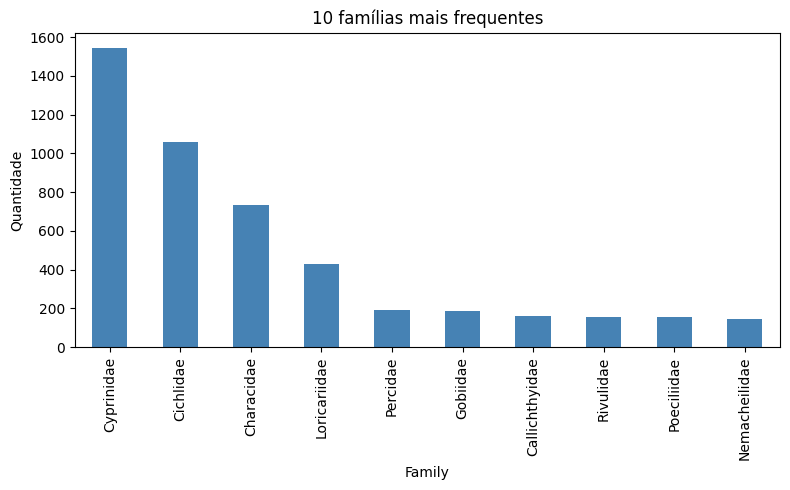

In [8]:
df['Family'].value_counts().head(10).plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.title('10 famílias mais frequentes')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()


# 4 - Divisão de treino e teste


In [9]:
X = df.drop(columns=['Family'])
y = df['Family']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Registros de treino:', X_train.shape[0])
print('Registros de teste:', X_test.shape[0])
print('Famílias somente no teste:', sorted(set(y_test) - set(y_train)))

Registros de treino: 6673
Registros de teste: 1669
Famílias somente no teste: ['Ambylopsidae', 'Bedotiidae', 'Blenniidae', 'Cheimarrhichthyidae', 'Depraneidae', 'Leiognathidae', 'Monodactylidae', 'Serrasalmidae', 'Sillaginidae', 'Valenciidae']


# 5 - Validação cruzada


In [10]:
modelo = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])

cv = KFold(n_splits=2, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy')

print('Acurácia em cada parte:', scores)
print(f'Acurácia média na validação: {scores.mean():.4f}')

Acurácia em cada parte: [0.57806413 0.5986211 ]
Acurácia média na validação: 0.5883


# 6 - GridSearchCV


In [11]:
param_grid = {
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'classifier__C': [0.1, 1, 5, 10],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid = GridSearchCV(
    modelo, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

melhor_modelo = grid.best_estimator_

print('Modelo: SVM de classificação (SVC), com padronização')
print('Melhores parâmetros:', grid.best_params_)
print(f'Acurácia média do melhor modelo na validação: {grid.best_score_:.4f}')
print('\nModelo selecionado:')
print(melhor_modelo)

Modelo: SVM de classificação (SVC), com padronização
Melhores parâmetros: {'classifier__C': 5, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Acurácia média do melhor modelo na validação: 0.6381

Modelo selecionado:
Pipeline(steps=[('scaler', StandardScaler()), ('classifier', SVC(C=5))])


# 7 - Acurácia e matriz de confusão

O gráfico mostra somente as 10 famílias mais frequentes no treino. Casos com família real ou prevista fora desse recorte não aparecem no gráfico. A acurácia e a matriz numérica completa consideram todas as famílias.

Acurácia: 0.633912522468544
Matriz de confusão completa:
[[0 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 6 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


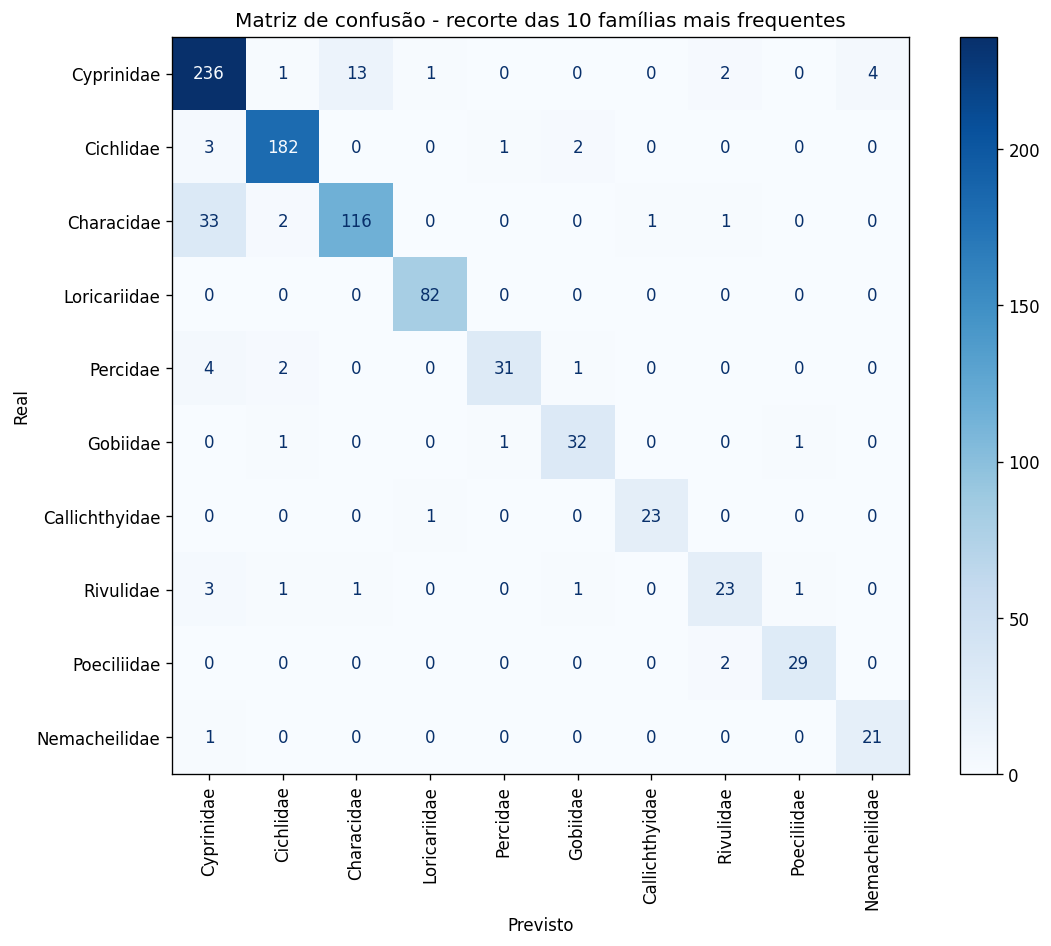

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = melhor_modelo.predict(X_test)
print('Acurácia:', accuracy_score(y_test, y_pred))
matriz = confusion_matrix(y_test, y_pred)
print('Matriz de confusão completa:')
print(matriz)

familias = y_train.value_counts().head(10).index
matriz_recorte = confusion_matrix(y_test, y_pred, labels=familias)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(matriz_recorte, display_labels=familias).plot(
    ax=ax, cmap='Blues', values_format='d', xticks_rotation=90
)
plt.title('Matriz de confusão - recorte das 10 famílias mais frequentes')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()
